### By Thanh Pham tp25449

# Introduction & System Selection

In this project, a stiff overdamped mechanical system was studied using numerical methods for stiff ordinary differential equations. The system models an overdamped spring-mass system with extremely high damping, which causes the system to respond on a very fast time scale. Because of this rapid response, explicit numerical methods require extremely small step sizes to remain stable, making the problem stiff.

The governing differential equation for the system is

$$
\frac{dx}{dt} = -5000x + 0.002\sin(t).
$$

In this equation, \(x(t)\) represents the displacement of the system from equilibrium in meters. The term $-5000x$ represents the strong damping effect that rapidly forces the system back toward equilibrium, while the forcing term $0.002\sin(t)$ represents a slowly varying external force applied to the system.

The parameter \(5000\) determines the rate at which the system relaxes back to equilibrium. Since this value is very large, the transient response decays extremely quickly, creating a large separation between the fast dynamics of the damping and the slower oscillation of the forcing function. This difference in time scales is what makes the equation stiff.

# Analytical Solution

Fortunately, this ODE has a closed form analytical solution.
Rewriting in standard linear form gives

$$
x' + 5000x = 0.002\sin(t).
$$

This equation can be solved using the method of integrating factors. For a first-order linear ODE of the form

$$
x' + p(t)x = q(t),
$$

the integrating factor is

$$
\mu(t) = e^{\int p(t)\,dt}.
$$

Since \(p(t)=5000\), the integrating factor is

$$
\mu(t)=e^{5000t}.
$$

Multiplying the differential equation by the integrating factor gives

$$
e^{5000t}x' + 5000e^{5000t}x
=
0.002e^{5000t}\sin(t).
$$

The left-hand side becomes

$$
\frac{d}{dt}\left(e^{5000t}x(t)\right).
$$

Integrating both sides and simplifying produces

$$
x(t)
=
Ce^{-5000t}
+
\frac{0.002}{5000^2+1}
\left(5000\sin(t)-\cos(t)\right).
$$

Using the initial condition \(x(0)=1\), the constant \(C\) is determined to be

$$
C = 1 + \frac{0.002}{25000001}.
$$

Therefore, the analytical solution is

$$
x(t)
=
\left(1+\frac{0.002}{25000001}\right)e^{-5000t}
+
\frac{10}{25000001}\sin(t)
-
\frac{0.002}{25000001}\cos(t).
$$

This exact solution was used to verify the accuracy of the numerical methods and compute numerical error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Stiff overdamped spring-mass system
#
# dx/dt = -5000x + 0.002sin(t)

lam = 5000
forcing_coeff = 0.002

x0 = 1.0
t_start = 0.0
t_end = 2.0


def f(t, x):
    return -lam*x + forcing_coeff*np.sin(t)


def exact_solution(t):
    # Solves x' + 5000x = 0.002sin(t)
    a = 10 / 25000001
    b = -0.002 / 25000001
    C = x0 - b

    return C*np.exp(-5000*t) + a*np.sin(t) + b*np.cos(t)


# Implementation of Numerical Methods

The numerical methods were implemented in Python using NumPy arrays to store the time values and solution values. The right-hand side of the differential equation was defined as a function,

$$
f(t,x) = -5000x + 0.002\sin(t),
$$

so that the same ODE function could be used in both Euler's Forward Method and Euler's Backward Method.

Euler's Forward Method was implemented explicitly using the update formula

$$
x_{n+1}=x_n+h f(t_n,x_n).
$$

This method directly computes the next value from the current value, so no equation-solving step is required. It was mainly used to demonstrate stiffness, since Forward Euler becomes unstable unless the step size is extremely small.

Euler's Backward Method was implemented using the implicit update formula

$$
x_{n+1}=x_n+h f(t_{n+1},x_{n+1}).
$$

Since \(x_{n+1}\) appears on both sides of the equation, Newton-Raphson was used at each time step to solve for the next value. The Newton iteration was stopped when the change between successive guesses satisfied

$$
|x^{(j+1)}-x^{(j)}|<10^{-6}.
$$

A maximum iteration limit of 20 was included to prevent infinite looping if convergence failed. The code also recorded the number of Newton-Raphson iterations required at each time step so that the computational cost of the implicit method could be analyzed.

### Mathematical Setup and Explanation

The stiff ODE is

$$
x' = -5000x + 0.002\sin(t).
$$

Using Backward Euler, the update formula is

$$
x_{n+1} = x_n + h f(t_{n+1}, x_{n+1}),
$$

where

$$
f(t,x) = -5000x + 0.002\sin(t).
$$

Since \(x_{n+1}\) appears on both sides of the Backward Euler formula, the equation is written as a residual function:

$$
R(x_{n+1}) =
x_{n+1}
-
x_n
-
h\left(-5000x_{n+1}+0.002\sin(t_{n+1})\right).
$$

The goal of Newton-Raphson is to solve

$$
R(x_{n+1}) = 0.
$$

The derivative of the residual with respect to \(x_{n+1}\) is

$$
R'(x_{n+1}) = 1 + 5000h.
$$

Newton-Raphson uses the iteration

$$
x^{(j+1)}
=
x^{(j)}
-
\frac{R(x^{(j)})}{R'(x^{(j)})}.
$$

Substituting the specific residual gives

$$
x^{(j+1)}
=
x^{(j)}
-
\frac{
x^{(j)}
-
x_n
-
h\left(-5000x^{(j)}+0.002\sin(t_{n+1})\right)
}{
1+5000h
}.
$$

Since this residual is linear in \(x_{n+1}\), Newton-Raphson converges very quickly, usually in one iteration and maximum two iterations for this problem (which can be later observed in this notebook).

In [3]:
#For the sake of demonstrating stiffness
# Forward Euler

def euler_forward(h):
    t_values = np.arange(t_start, t_end + h, h)
    x_values = np.zeros(len(t_values))

    x_values[0] = x0

    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        x_n = x_values[i - 1]

        x_values[i] = x_n + h*f(t_n, x_n)

    return t_values, x_values

In [4]:
# Newton-Raphson solver for Backward Euler

def newton_solver(x_n, t_next, h, tol=1e-6, max_iter=20):
    # Forward Euler step as initial guess
    x_guess = x_n + h*f(t_next, x_n) #y_n also works 

    for iteration in range(1, max_iter + 1):

        # Residual:
        # R(x_next) = x_next - x_n - h*f(t_next, x_next)
        R = x_guess - x_n - h*f(t_next, x_guess)

        # For f(t,x) = -5000x + 0.002sin(t),
        # taking partial derivative w.r.t to x: dR/dx = 1 - h*(-5000) = 1 + 5000h
        dRdx = 1 + lam*h

        x_new = x_guess - R/dRdx

        if abs(x_new - x_guess) < tol:
            return x_new, iteration

        x_guess = x_new

    print("Warning: Newton-Raphson did not converge.")
    return x_guess, max_iter


# Backward Euler using Newton-Raphson


def euler_backward(h):
    #initiate empty arrays for recording solution
    t_values = np.arange(t_start, t_end + h, h)
    x_values = np.zeros(len(t_values))
    iteration_counts = np.zeros(len(t_values))

    x_values[0] = x0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        x_n = x_values[i - 1]

        x_next, iterations = newton_solver(x_n, t_next, h)

        x_values[i] = x_next
        iteration_counts[i] = iterations

    return t_values, x_values, iteration_counts



In [5]:
# Run multiple step sizes

forward_step_sizes = [0.0001, 0.0002, 0.0004, 0.001, 0.01, 0.1]
backward_step_sizes = [0.0001, 0.0002, 0.0004, 0.001, 0.01, 0.1]

forward_results = []
backward_results = []

for h in forward_step_sizes:
    t, x = euler_forward(h)
    forward_results.append([h, t, x])

for h in backward_step_sizes:
    t, x, iterations = euler_backward(h)
    backward_results.append([h, t, x, iterations])

<ipython-input-2-6df1d2831c4a>:14: RuntimeWarning: overflow encountered in double_scalars
  return -lam*x + forcing_coeff*np.sin(t)
<ipython-input-3-14221bcbbcd1>:14: RuntimeWarning: invalid value encountered in double_scalars
  x_values[i] = x_n + h*f(t_n, x_n)


The overflow warnings occur because Forward Euler is numerically unstable for the larger step sizes, causing the computed solution to grow beyond the range Python can represent. This is expected and supports the stiffness demonstration.

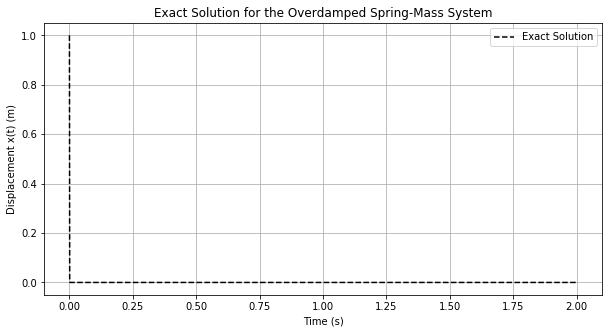

In [6]:
plt.figure(figsize=(10,5))
t_exact = np.linspace(t_start, t_end, 2000)
x_exact = exact_solution(t_exact)

plt.plot(t_exact, x_exact, "k--", label="Exact Solution")

plt.title("Exact Solution for the Overdamped Spring-Mass System")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

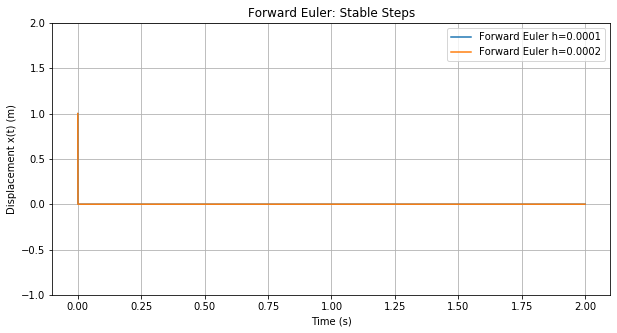

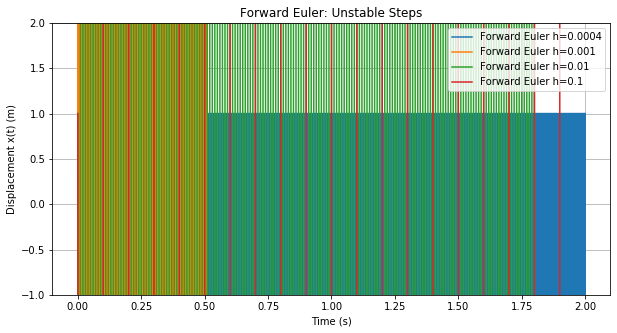

In [7]:
# Plot Forward Euler stiffness demonstration

plt.figure(figsize=(10, 5))

for result in forward_results[:2]:
    h = result[0]
    t = result[1]
    x = result[2]

    plt.plot(t, x, label=f"Forward Euler h={h}")

plt.title("Forward Euler: Stable Steps")
plt.ylim(-1,2)
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

for result in forward_results[2:]:
    h = result[0]
    t = result[1]
    x = result[2]

    plt.plot(t, x, label=f"Forward Euler h={h}")

plt.title("Forward Euler: Unstable Steps")
plt.ylim(-1,2)
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

# Demonstration of Stiffness and Stability Analysis for Euler Forward
Stiffness is visually characterized by the extremely fast decay in the beginning and then the near constant behavior after.
The stiffness comes from the large negative coefficient in the term \(-5000x\). If we isolate the homogeneous part of the equation,

$$
x' = -5000x,
$$

then the solution decays like

$$
x(t) = Ce^{-5000t}.
$$

This gives a fast decay time scale of

$$
t_{\text{fast}} = \frac{1}{5000} = 0.0002 \text{ s}.
$$

However, the forcing term $\sin(t)$ changes on a much slower time scale, approximately

$$
t_{\text{slow}} \approx 1 \text{ s}.
$$

Therefore, the stiffness ratio can be estimated as

$$
\frac{t_{\text{slow}}}{t_{\text{fast}}}
=
\frac{1}{0.0002}
=
5000.
$$

This large separation between the fast transient decay and the slow forcing behavior shows that the problem is stiff. Even though the long-term solution changes slowly, explicit methods such as Euler's Forward Method must use a step size small enough to resolve the very fast transient. This is why Forward Euler requires extremely small step sizes for stability.

For Euler's Forward Method, the stability condition is determined by the homogeneous part \(x'=-5000x\). Applying Forward Euler gives

$$
x_{n+1}
=
x_n + h(-5000x_n)
=
(1-5000h)x_n.
$$

For stability, the amplification factor must satisfy

$$
|1-5000h| < 1.
$$

Solving this inequality gives

$$
0<h<\frac{2}{5000}=0.0004.
$$

Thus, Forward Euler requires a step size smaller than \(0.0004\) seconds to remain stable. For the full simulation interval $0\leq t\leq 2$, this requires at least

$$
\frac{2}{0.0004}=5000
$$

time steps. Since \(h=0.0004\) is only the borderline stability value, a safer stable step size such as \(h=0.0002\) would require

$$
\frac{2}{0.0002}=10000
$$

time steps.

This demonstrates the impracticality of explicit methods for this stiff problem. Although the long-term behavior of the solution changes slowly, Forward Euler is forced to use extremely small step sizes only because of the fast transient component. This creates a large computational burden compared to implicit methods such as Euler's Backward Method, which can remain stable using much larger step sizes.

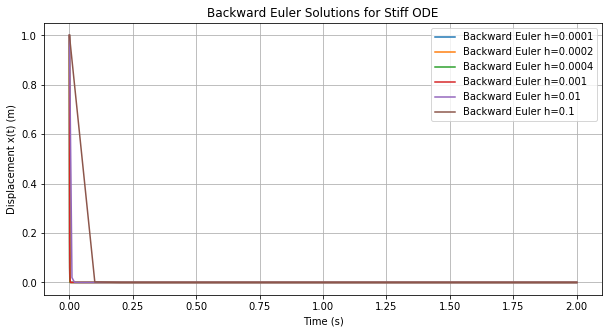

In [8]:
# Plot Backward Euler solutions
plt.figure(figsize=(10, 5))

for result in backward_results:
    h = result[0]
    t = result[1]
    x = result[2]

    plt.plot(t, x, label=f"Backward Euler h={h}")


plt.title("Backward Euler Solutions for Stiff ODE")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.legend()
plt.grid(True)
plt.show()

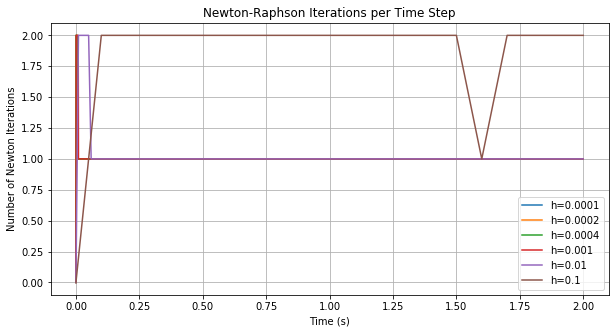

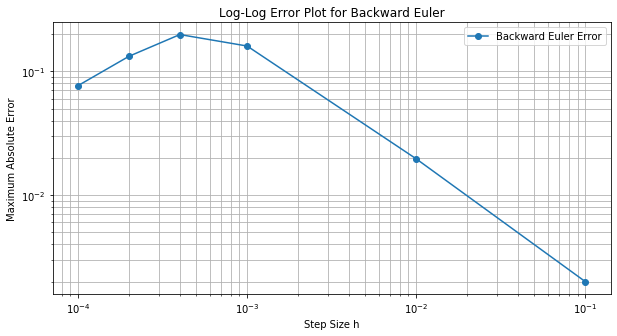

Backward Euler Performance
--------------------------------------------------------------
h		steps	avg NR iters	total NR iters	function evals
0.0001		20000	1.00		20030		40030
0.0002		10000	1.00		10019		20019
0.0004		5000	1.00		5013		10013
0.0010		2000	1.00		2009		4009
0.0100		200	1.02		205		405
0.1000		20	1.95		39		59


In [9]:
# Newton-Raphson iterations vs time

plt.figure(figsize=(10, 5))

for result in backward_results:
    h = result[0]
    t = result[1]
    iterations = result[3]

    plt.plot(t, iterations, label=f"h={h}")

plt.title("Newton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("Number of Newton Iterations")
plt.legend()
plt.grid(True)
plt.show()


# Error vs step size for Backward Euler

backward_errors = []

for result in backward_results:
    h = result[0]
    t = result[1]
    x = result[2]

    x_exact = exact_solution(t)

    error = np.max(np.abs(x - x_exact))
    backward_errors.append(error)

plt.figure(figsize=(10, 5))

plt.loglog(backward_step_sizes, backward_errors, "o-", label="Backward Euler Error")

plt.title("Log-Log Error Plot for Backward Euler")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Absolute Error")
plt.legend()
plt.grid(True, which="both")
plt.show()


# Cost table

print("Backward Euler Performance")
print("--------------------------------------------------------------")
print("h\t\tsteps\tavg NR iters\ttotal NR iters\tfunction evals")

for result in backward_results:
    h = result[0]
    t = result[1]
    iterations = result[3]

    steps = len(t) - 1
    avg_iters = np.mean(iterations[1:])
    total_iters = np.sum(iterations[1:])

    # One f evaluation for the predictor, then one f evaluation per Newton iteration
    total_function_evals = steps + total_iters

    print(f"{h:.4f}\t\t{steps}\t{avg_iters:.2f}\t\t{int(total_iters)}\t\t{int(total_function_evals)}")


# Stability Analysis and Comparison

Most of the stiffness analysis was already established by testing Euler’s Forward Method and deriving its stability condition. For the stiff decay term,

$$
x'=-5000x,
$$

Euler’s Forward Method is stable only when

$$
|1-5000h|<1,
$$

so

$$
0<h<0.0004.
$$

This means that explicit Euler requires extremely small step sizes, even though the solution is being computed over the much larger interval $0\leq t\leq 2$. In contrast, Euler’s Backward Method is stable for much larger step sizes because it evaluates the derivative implicitly at the next time step.

| Method | Stability Behavior | Practical Step Size Range Used |
|---|---|---|
| Euler’s Forward Method | Stable only for \(h<0.0004\) | \(h=0.0002\) or smaller |
| Euler’s Backward Method | Stable for much larger \(h\) values | \(h=0.001,\ 0.01,\ 0.05,\ 0.1\) |

For computational cost, Euler’s Backward Method requires more work per time step because Newton-Raphson must be used to solve the implicit equation. However, for this problem the residual equation is linear, so Newton-Raphson converges very quickly. In most cases, the method only requires about one iteration per time step. This makes Backward Euler computationally efficient despite being implicit.

The solution quality was checked by comparing the numerical solution with the analytical solution. Backward Euler remained stable for larger step sizes, but larger $h$ values still reduced accuracy. This shows an important distinction: stability does not automatically mean accuracy. A method can remain bounded and physically reasonable while still failing to resolve the fast initial transient accurately.

For this stiff system, the physically expected behavior is a rapid decay from the initial condition followed by a small, slowly varying forced response. Backward Euler correctly preserves this qualitative behavior for much larger step sizes than Forward Euler. However, to capture the very fast transient near $t=0$, smaller step sizes are still needed. Therefore, the best method depends on the goal: if the goal is stability and long-term behavior, Backward Euler can use large step sizes; if the goal is to accurately resolve the initial fast transient, a smaller step size is still necessary.

# Conclusions

This project showed that the overdamped spring system is stiff because it contains a very fast transient decay compared to the slower external forcing. Euler’s Forward Method became unstable unless the step size was extremely small, while Euler’s Backward Method remained stable for much larger step sizes and produced solutions that better matched the expected physical behavior.

The main conclusion is that explicit methods are simple and inexpensive per step, but they are not practical for stiff problems because their stability restrictions can force very small step sizes. Implicit methods such as Euler’s Backward Method require more work per step because an equation must be solved at each time step, but they are much better suited for stiff systems because they can remain stable with larger step sizes.

# Notes and Citations
AI was used in the completion of this project. Many of the formatting of equations and tables was done by AI (b/c LaTeX is hard). The log-log error plot was also done by AI.